In [1]:
from timescale import TimescaleDBManager
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import joblib
import json
import re
from functools import partial

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,accuracy_score, precision_score, recall_score, f1_score,classification_report
from sklearn.metrics import classification_report

from sklearn.inspection import permutation_importance

from sklearn.preprocessing import LabelEncoder


from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense,BatchNormalization, Dropout, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.callbacks import EarlyStopping

from scikeras.wrappers import KerasRegressor
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import optuna
import tensorflow as tf
import seaborn as sns







In [2]:
load_dotenv()
user_env        = os.getenv("USER_DB")
pass_env        = os.getenv("PASS_DB")
host_env        = os.getenv("HOST_DB", "localhost")
port_env        = os.getenv("DB_PORT_EXPOSED", "5432")
db_env          = os.getenv("NAME_DB", "tfm_db")
FOLDER_SALIDA   = os.getenv("FOLDER_SALIDA")
FOLDER_TMP      = os.getenv("FOLDER_TMP")

SEED            = 100#int(os.getenv("SEED"))

db = TimescaleDBManager(
    user=user_env,
    password=pass_env,
    host=host_env,
    port=port_env,
    dbname=db_env
)
db.conectar()
conexion_postgresql = db.connection

#esto es para usar una conexion postgrews para pandas que da un warning indicando que solo esta testeado para sqlalchemy
engine = create_engine(f'postgresql+psycopg2://{user_env}:{pass_env}@{host_env}:{port_env}/{db_env}')

🔌 [OK] Conexión establecida con TimescaleDB.


In [3]:
SQL='select * from vectores'
df = pd.read_sql(SQL, engine)


In [4]:
lista_label = df['label'].unique().tolist()

In [5]:
len(lista_label)

54

In [6]:
df_result=df[ ['vector_id','execution_name','label'] ].copy()
df_result['split_type'] = 'unknown'

In [7]:
df_result

,vector_id,execution_name,label,split_type
0,90244,light-oauth2-data-1719592986.tar,correct,unknown
1,90245,light-oauth2-data-1719592986.tar,correct,unknown
2,90246,light-oauth2-data-1719592986.tar,correct,unknown
3,90247,light-oauth2-data-1719592986.tar,correct,unknown
4,90333,light-oauth2-data-1719594842.tar,invalid_code_verifier_format_PKCE_400,unknown
...,...,...,...,...
90185,180429,light-oauth2-data-1725866154.tar,delete_user_404_no_user,unknown
90186,180430,light-oauth2-data-1725866154.tar,update_password_401_wrong_password,unknown
90187,180431,light-oauth2-data-1725866154.tar,update_password_404_user_not_found,unknown
90188,180432,light-oauth2-data-1725866154.tar,update_password_400_not_match,unknown


In [8]:
filename = f'{FOLDER_SALIDA}/lista_metric_name_vector.json'

with open(filename, "r", encoding="utf-8") as f:
    lista_metric_name_vector = json.load(f)

# <span style="color:#2ca02c">1. Separamos conjuntos de train, val y test</span>

<span style="color:#2ca02c">Por cada label dividimos los datos en train, val y test</span>


In [9]:
dic_idx_train = {}
dic_idx_resto = {}
dic_idx_val   = {}
dic_idx_test  = {}

In [10]:
for label in lista_label:
    indices = df[ df['label']== label ].index.values
    idx_train, idx_resto = train_test_split(indices   , test_size=0.4 , random_state=SEED)
    idx_val,   idx_test  = train_test_split(idx_resto , test_size=0.5 , random_state=SEED)
    df_result.loc[idx_train , 'split_type'] = 'train'
    df_result.loc[idx_val   , 'split_type'] = 'val'
    df_result.loc[idx_test  , 'split_type'] = 'test'
    dic_idx_train[label] = idx_train
    dic_idx_resto[label] = idx_resto
    dic_idx_val[label]   = idx_val
    dic_idx_test[label]  = idx_test

df_reparto = pd.DataFrame({
    'Cantidad': df_result['split_type'].value_counts(),
    'Porcentaje (%)': (df_result['split_type'].value_counts(normalize=True) * 100).round(2)
})

print("Reparto porcentual de los datos:")
display(df_reparto)

Reparto porcentual de los datos:


,Cantidad,Porcentaje (%)
split_type,,
train,54093,59.98
test,18058,20.02
val,18039,20.00


In [11]:
df_result

,vector_id,execution_name,label,split_type
0,90244,light-oauth2-data-1719592986.tar,correct,test
1,90245,light-oauth2-data-1719592986.tar,correct,test
2,90246,light-oauth2-data-1719592986.tar,correct,train
3,90247,light-oauth2-data-1719592986.tar,correct,test
4,90333,light-oauth2-data-1719594842.tar,invalid_code_verifier_format_PKCE_400,train
...,...,...,...,...
90185,180429,light-oauth2-data-1725866154.tar,delete_user_404_no_user,val
90186,180430,light-oauth2-data-1725866154.tar,update_password_401_wrong_password,val
90187,180431,light-oauth2-data-1725866154.tar,update_password_404_user_not_found,train
90188,180432,light-oauth2-data-1725866154.tar,update_password_400_not_match,train


<span style="color:#2ca02c"> Convetimos los vectores del df en una matriz, seran los datos que pasemos a los algoritmo   </span>


In [12]:
X_matrix = np.array(df['vector'].tolist())
X_matrix.shape

(90190, 354)

# <span style="color:#2ca02c">2. Separación de grupos de datos</span>

In [13]:
lista_result=[]

In [14]:
idx_correct_train = dic_idx_train['correct']
idx_correct_val   = dic_idx_val['correct']
idx_correct_test  = dic_idx_test['correct']

In [15]:
N_datos_test_por_anomalia = int( len(idx_correct_test)  / (len(lista_label)-1) )

In [16]:
idx_test =idx_correct_test.copy()
for label in lista_label:
    if label=='correct':
        continue
    if len(dic_idx_test[label])<N_datos_test_por_anomalia:
        idx_test = np.concatenate((idx_test, dic_idx_test[label]))
    else:
        #idx_test.extend(dic_idx_test[label][:N_datos_test_por_anomalia])
        # Corrección: pon los dos arrays dentro de un paréntesis
        idx_test = np.concatenate((idx_test, dic_idx_test[label][:N_datos_test_por_anomalia]))
        
X_test  = X_matrix[idx_test]

In [17]:
len(idx_correct_train)

10231

In [18]:
idx_correct_val

array([25045, 66835, 26997, ..., 22924,  4164, 66475], shape=(3410,))

In [19]:
idx_correct_test

array([61664, 86260, 20906, ..., 52462, 30786, 57609], shape=(3411,))

In [20]:
X_matrix.shape

(90190, 354)

In [21]:
X_correct_train = X_matrix[idx_correct_train]
X_correct_test  = X_matrix[idx_correct_test]

In [22]:
idx_correct_test.shape

(3411,)

In [23]:
 df.loc[idx_correct_test].shape

(3411, 5)

In [24]:
df.shape

(90190, 5)

In [25]:
df_result = pd.DataFrame({
    't_rel': df.loc[idx_test, 't_rel'],
    'execution_name': df.loc[idx_correct_test, 'execution_name'],
    'label': df.loc[idx_test, 'label']
})

# <span style="color:#2ca02c">3. Detección de anomalías</span>

## <span style="color:#2ca02c">3.1. Optimizacion con optuna</span>

In [26]:
def create_autoencoder(latent_dim, hidden_units, learning_rate, input_dim):
    # Capa de entrada
    input_layer = layers.Input(shape=(input_dim,))
    
    # Encoder
    h = layers.Dense(hidden_units, activation='relu')(input_layer)
    latent = layers.Dense(latent_dim, activation='relu')(h)
    
    # Decoder (simétrico al encoder)
    h_decode = layers.Dense(hidden_units, activation='relu')(latent)
    output_layer = layers.Dense(input_dim, activation='linear')(h_decode)
    
    # Construir modelo
    autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
    
    # Compilar modelo
    autoencoder.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse'
    )
    
    return autoencoder

In [27]:
def print_callback(study, trial):
    p = trial.params
    # Leemos el atributo que guardamos en el trial
    actual_epochs = trial.user_attrs.get('actual_epochs', 'N/D')
    max_epochs = p.get('epochs')
    
    print(f"[Probando] Latent Dim: {p.get('latent_dim')} | Ocultas: {p.get('hidden_units')} | "
          f"LR: {p.get('learning_rate')} | Batch: {p.get('batch_size')} | "
          f"Épocas: {actual_epochs}/{max_epochs} (reales/máx) "
          f"-> Fin de entrenamiento | Loss (MSE) final: {trial.value:.6f}")


In [28]:
# 2. Función objetivo de Optuna recibiendo el diccionario externo
def objective(trial, config):
    latent_dim = trial.suggest_categorical('latent_dim', config['latent_dim'])
    hidden_units = trial.suggest_categorical('hidden_units', config['hidden_units'])
    learning_rate = trial.suggest_categorical('learning_rate', config['learning_rate'])
    batch_size = trial.suggest_categorical('batch_size', config['batch_size'])
    epochs = trial.suggest_categorical('epochs', config['epochs'])
    
    #input_dim = X_correct_train.shape[1]
    
    # Instanciar el modelo usando tu función
    autoencoder = create_autoencoder(
        latent_dim=latent_dim, 
        hidden_units=hidden_units, 
        learning_rate=learning_rate, 
        input_dim=input_dim
    )
    
    early_stopping = EarlyStopping(
        monitor='loss', 
        patience=3, 
        restore_best_weights=True
    )
    
    history = autoencoder.fit(
        X_correct_train, X_correct_train,
        batch_size=batch_size,
        epochs=epochs,
        callbacks=[early_stopping],
        verbose=0
    )

    #recuperamos el numero de epocas realizadas para mostrarlas en el resultado
    actual_epochs = len(history.history['loss'])
    trial.set_user_attr('actual_epochs', actual_epochs)
    
    #return history.history['loss'][-1]
    return min(history.history['loss'])




In [30]:
input_dim = X_correct_train.shape[1]

# 1. Definición externa de los hiperparámetros a probar
params_grid = {
    'latent_dim': [8, 16, 32],
    'hidden_units': [48, 64, 96],
    'learning_rate': [0.005, 0.0001],
    'batch_size': [32, 64],
    'epochs': [100]
}

# 2. Crear el estudio
study = optuna.create_study(direction='minimize')

# 3. Enlazar la función con los parámetros mediante partial
objective_func = partial(objective, config=params_grid)

# 4. Ejecutar pasándole 'objective_func' (NO 'objective')
study.optimize(objective_func, n_trials=100, callbacks=[print_callback],n_jobs=-1)

# 5.Resultados finales
print("\n=== MEJOR COMBINACIÓN ENCONTRADA ===")
print(study.best_params)
print(f"Mejor Loss (MSE): {study.best_value:.6f}")

[I 2026-07-24 17:24:21,601] A new study created in memory with name: no-name-e5a732b2-b356-44ae-9ad6-40a0394bd808


[I 2026-07-24 17:26:47,461] Trial 30 finished with value: 0.18204179406166077 and parameters: {'latent_dim': 8, 'hidden_units': 64, 'learning_rate': 0.005, 'batch_size': 64, 'epochs': 100}. Best is trial 30 with value: 0.18204179406166077.


[Probando] Latent Dim: 8 | Ocultas: 64 | LR: 0.005 | Batch: 64 | Épocas: 34/100 (reales/máx) -> Fin de entrenamiento | Loss (MSE) final: 0.182042


[I 2026-07-24 17:26:56,589] Trial 27 finished with value: 0.18430601060390472 and parameters: {'latent_dim': 8, 'hidden_units': 96, 'learning_rate': 0.005, 'batch_size': 64, 'epochs': 100}. Best is trial 30 with value: 0.18204179406166077.


[Probando] Latent Dim: 8 | Ocultas: 96 | LR: 0.005 | Batch: 64 | Épocas: 36/100 (reales/máx) -> Fin de entrenamiento | Loss (MSE) final: 0.184306


...

[Probando] Latent Dim: 32 | Ocultas: 96 | LR: 0.0001 | Batch: 64 | Épocas: 100/100 (reales/máx) -> Fin de entrenamiento | Loss (MSE) final: 0.117023
[Probando] Latent Dim: 32 | Ocultas: 96 | LR: 0.0001 | Batch: 64 | Épocas: 100/100 (reales/máx) -> Fin de entrenamiento | Loss (MSE) final: 0.119341


[I 2026-07-24 17:49:34,001] Trial 96 finished with value: 0.12176794558763504 and parameters: {'latent_dim': 32, 'hidden_units': 96, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 100}. Best is trial 72 with value: 0.11140559613704681.


[Probando] Latent Dim: 32 | Ocultas: 96 | LR: 0.0001 | Batch: 64 | Épocas: 100/100 (reales/máx) -> Fin de entrenamiento | Loss (MSE) final: 0.121768


[I 2026-07-24 17:49:34,210] Trial 99 finished with value: 0.11780015379190445 and parameters: {'latent_dim': 32, 'hidden_units': 96, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 100}. Best is trial 72 with value: 0.11140559613704681.
[I 2026-07-24 17:49:34,288] Trial 98 finished with value: 0.111726775765419 and parameters: {'latent_dim': 32, 'hidden_units': 96, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 100}. Best is trial 72 with value: 0.11140559613704681.


[Probando] Latent Dim: 32 | Ocultas: 96 | LR: 0.0001 | Batch: 64 | Épocas: 100/100 (reales/máx) -> Fin de entrenamiento | Loss (MSE) final: 0.117800
[Probando] Latent Dim: 32 | Ocultas: 96 | LR: 0.0001 | Batch: 64 | Épocas: 100/100 (reales/máx) -> Fin de entrenamiento | Loss (MSE) final: 0.111727

=== MEJOR COMBINACIÓN ENCONTRADA ===
{'latent_dim': 32, 'hidden_units': 96, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 100}
Mejor Loss (MSE): 0.111406


## <span style="color:#2ca02c">3.2. Entrenamiento profundo del AE con los hiperparámetros optimizados</span>

In [13]:
input_dim = X_correct_train.shape[1]

#1. Recuperamos los parametros de la optimizacion

best_params = study.best_params
print("=== CONFIGURACIÓN DEFINITIVA ===")
print(best_params)

# 2. Instanciar el modelo usando TU función original de creación
#input_dim = X_correct_train.shape[1]
autoencoder_final = create_autoencoder(
    latent_dim=best_params['latent_dim'],
    hidden_units=best_params['hidden_units'],
    learning_rate=best_params['learning_rate'],
    input_dim=input_dim
)

# 3. Configurar Early Stopping con más paciencia para exprimir el entrenamiento
early_stopping_final = EarlyStopping(
    monitor='loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# 4. Entrenar con un número mayor de épocas (ej: 200) respaldado por tu función
epochs_final = 500

print("\nIniciando entrenamiento del modelo definitivo...")
history_final = autoencoder_final.fit(
    X_correct_train, X_correct_train,
    batch_size=best_params['batch_size'],
    epochs=epochs_final,
    callbacks=[early_stopping_final],
    verbose=1  # verbose=1 para ver la evolución en directo
)

print(f"\n¡Entrenamiento finalizado!")
print(f"Épocas reales ejecutadas: {len(history_final.history['loss'])} / {epochs_final}")
print(f"Loss (MSE) final: {history_final.history['loss'][-1]:.6f}")

NameError: name 'X_correct_train' is not defined

In [36]:
autoencoder = autoencoder_final

In [51]:
# 1. Calculas los errores en el train limpio
reconstructions_train = autoencoder.predict(X_correct_train)
train_scores = np.mean(np.power(X_correct_train - reconstructions_train, 2), axis=1)

# 2. Defines el umbral basándote en el train (ej. el percentil 95 o 99 de los normales)
threshold_percentil_scores = 99.9
threshold = np.percentile(train_scores, threshold_percentil_scores)

320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 639us/step



Calculando errores de reconstrucción en el conjunto de test...
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step


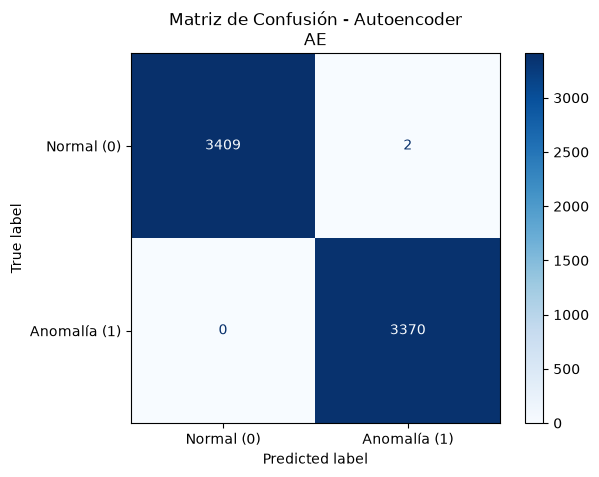

In [55]:
# Calcular los scores (Error de reconstrucción MSE por muestra) para X_test
print("\nCalculando errores de reconstrucción en el conjunto de test...")
reconstructions = autoencoder.predict(X_test)
scores = np.mean(np.power(X_test - reconstructions, 2), axis=1)

reconstructions_train = autoencoder.predict(X_correct_train)
train_scores = np.mean(np.power(X_correct_train - reconstructions_train, 2), axis=1)


# Predicción: Si el MSE supera el umbral es anomalía (1), si no, normal (0)
Y_pred = np.where(scores > threshold, 1, 0)

model_name = f'AE'



df_result[f'result_({model_name})'] = float('nan')
df_result[f'scores_({model_name})'] = float('nan')
df_result.loc[idx_test, f'result_({model_name})'] = Y_pred
df_result.loc[idx_test, f'scores_({model_name})'] = scores

# Mapeo de etiquetas reales (0 = normal/correct, 1 = anomalía)
y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
y_pred = df_result.loc[idx_test, f'result_({model_name})']

# 1. Componentes de la matriz de confusión
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

# 2. Cálculo de métricas
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred, zero_division=0)

parametros = best_params.copy()
parametros['threshold_percentil_scores'] = threshold_percentil_scores


# 3. Guardar en el registro
reg_resultado_algoritmo = {
    'test_name': model_name,
    'parametros': json.dumps(parametros),
    'TP': int(tp),
    'FP': int(fp),
    'TN': int(tn),
    'FN': int(fn),
    'accuracy': float(acc),
    'precision': float(precision),
    'recall': float(recall),
    'specificity': float(specificity),
    'f1_score': float(f1)
}

# Si quieres mantener la estructura de lista para un DataFrame posterior:
lista_result.append(reg_resultado_algoritmo)
df_anomaly_detection_summary = pd.DataFrame(lista_result)

# 4. Visualizar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomalía (1)'])
disp.plot(cmap='Blues')
plt.title(f'Matriz de Confusión - Autoencoder\n{model_name}')
plt.show()

In [37]:
paquete_autoencoder = {
    'model': autoencoder_final,                # El modelo de Keras ya entrenado
    'metrics_list': lista_metric_name_vector,  # La lista con los nombres de las características
    'model_name': "Autoencoder_TFM_Microservices", # Un identificador o nombre descriptivo
    'parametros': parametros           # Opcional: guardar los hiperparámetros ganadores
}
joblib.dump(paquete_autoencoder, f'{FOLDER_SALIDA}/models/{model_name}.joblib')

['result/models/AE.joblib']

In [40]:
df_anomaly_detection_summary

,test_name,parametros,TP,FP,TN,FN,accuracy,precision,recall,specificity,f1_score
0,AE,"{""latent_dim"": 32, ""hidden_units"": 64, ""learni...",3370,3,3408,0,0.999558,0.999111,1.0,0.99912,0.999555


In [41]:
df_anomaly_detection_summary.to_parquet(f'{FOLDER_SALIDA}/df_anomaly_detection_AE_summary.parquet', index=False,engine='fastparquet')

# <span style="color:#2ca02c">4. Clasificacion de anomalias</span>

## <span style="color:#2ca02c">4.1 Clasificador Random Forest con métricas originales</span>

In [26]:
ruta_modelo = f'{FOLDER_SALIDA}/models/AE.joblib'
paquete_recuperado = joblib.load(ruta_modelo)
autoencoder_final = paquete_recuperado['model']
best_params=paquete_recuperado['parametros']


In [27]:

idx_train = np.array([], dtype=int)
idx_test  = np.array([], dtype=int)

In [28]:
for label in lista_label:
    if label=='correct':
        continue
    idx_train_tmp = dic_idx_train[label]
    idx_train     = np.concatenate((idx_train , idx_train_tmp))
    idx_test_tmp  = dic_idx_test[label]
    idx_test      = np.concatenate((idx_test  , idx_test_tmp ))
    
    

In [29]:
X_anomalia_train = X_matrix[idx_train]
X_anomalia_test  = X_matrix[idx_test]

In [30]:
X_anomalia_train.shape

(43862, 354)

In [31]:
df_result

,t_rel,execution_name,label
0,5.0,light-oauth2-data-1719592986.tar,correct
1,10.0,light-oauth2-data-1719592986.tar,correct
3,20.0,light-oauth2-data-1719592986.tar,correct
26,45.0,light-oauth2-data-1719592986.tar,correct
92,15.0,light-oauth2-data-1719594842.tar,correct
...,...,...,...
90130,30.0,light-oauth2-data-1725866154.tar,correct
90144,210.0,NaN,register_service_400_service_id
90145,225.0,NaN,register_service_400_service_type
90164,500.0,NaN,access_token_authorization_form_401


In [32]:
Y_train_etiquetas = df.loc[idx_train , 'label']
Y_test_etiquetas  = df.loc[idx_test  , 'label']

In [33]:
len(Y_train_etiquetas)

43862

In [34]:
df_result

,t_rel,execution_name,label
0,5.0,light-oauth2-data-1719592986.tar,correct
1,10.0,light-oauth2-data-1719592986.tar,correct
3,20.0,light-oauth2-data-1719592986.tar,correct
26,45.0,light-oauth2-data-1719592986.tar,correct
92,15.0,light-oauth2-data-1719594842.tar,correct
...,...,...,...
90130,30.0,light-oauth2-data-1725866154.tar,correct
90144,210.0,NaN,register_service_400_service_id
90145,225.0,NaN,register_service_400_service_type
90164,500.0,NaN,access_token_authorization_form_401


In [36]:
X_anomalia_train.shape

(43862, 354)

In [37]:
X_anomalia_train.shape

(43862, 354)

In [38]:
Y_train_etiquetas.shape

(43862,)

=== REPORTE DE CLASIFICACIÓN DE TIPOS DE ANOMALÍA ===
                                               precision    recall  f1-score   support

           access_token_auth_header_error_401       0.54      0.54      0.54       290
          access_token_authorization_form_401       0.56      0.64      0.60       297
         access_token_client_id_not_found_404       0.59      0.63      0.61       307
         access_token_client_secret_wrong_401       0.59      0.54      0.56       287
             access_token_form_urlencoded_400       0.64      0.65      0.64       310
          access_token_illegal_grant_type_400       0.56      0.59      0.58       306
access_token_missing_authorization_header_400       0.57      0.57      0.57       299
     authorization_code_client_id_missing_400       0.56      0.60      0.58       282
     authorization_code_invalid_client_id_404       0.53      0.51      0.52       299
      authorization_code_invalid_password_401       0.60      0.72      0.6

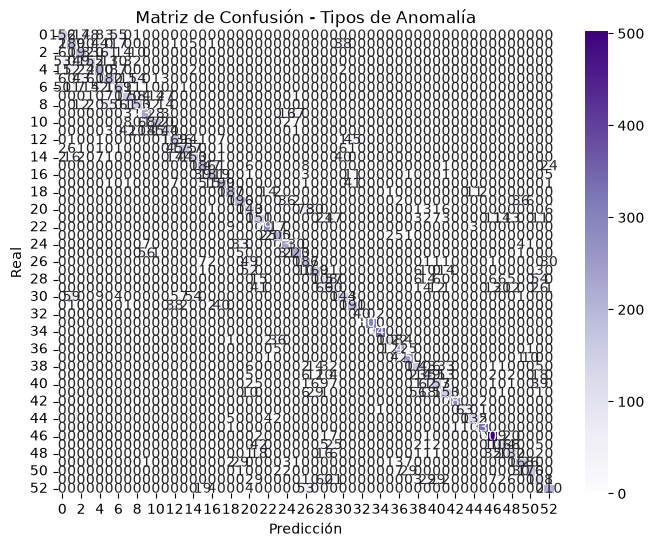

In [27]:
# 1. Instanciar el clasificador de tipos de anomalía
clf_anomalias = RandomForestClassifier(random_state=SEED, n_estimators=100)

# 2. Entrenar el modelo con los datos de entrenamiento
clf_anomalias.fit(X_anomalia_train, Y_train_etiquetas)

# 3. Generar las predicciones del tipo de anomalía sobre el conjunto de test
Y_pred_tipos = clf_anomalias.predict(X_anomalia_test)

# 4. Evaluar el rendimiento del clasificador usando las etiquetas reales de test
print("=== REPORTE DE CLASIFICACIÓN DE TIPOS DE ANOMALÍA ===")
print(classification_report(Y_test_etiquetas, Y_pred_tipos))

# 5. Visualizar la Matriz de Confusión con las etiquetas de test
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(Y_test_etiquetas, Y_pred_tipos), annot=True, fmt='d', cmap='Purples')
plt.title("Matriz de Confusión - Tipos de Anomalía")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [28]:
cm = confusion_matrix(Y_test_etiquetas, Y_pred_tipos)

# Obtener los índices donde hay errores (fuera de la diagonal)
# y ordenarlos de mayor a menor número de errores
errores = []
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j and cm[i, j] > 0:  # Solo fuera de la diagonal y con errores
            # Guardar: (valor_error, etiqueta_real, etiqueta_predicha)
            errores.append((cm[i, j], i, j))

# Ordenar por cantidad de errores descendente
errores.sort(key=lambda x: x[0], reverse=True)

# Mostrar los 10 errores más comunes
print("=== TOP 10 PEORES CONFUSIONES ENTRE CLASES ===")
for count, i, j in errores[:10]:
    # Mapear el índice 'i' y 'j' al nombre real de la etiqueta si tienes una lista
    # label_names = ['nombre_0', 'nombre_1', ...]
    # print(f"Confusión: {label_names[i]} -> {label_names[j]} : {count} veces")
    print(f"Confusión (Índices): Clase {i} -> Clase {j} : {count} veces")

=== TOP 10 PEORES CONFUSIONES ENTRE CLASES ===
Confusión (Índices): Clase 20 -> Clase 26 : 78 veces
Confusión (Índices): Clase 10 -> Clase 9 : 68 veces
Confusión (Índices): Clase 47 -> Clase 48 : 68 veces
Confusión (Índices): Clase 29 -> Clase 28 : 66 veces
Confusión (Índices): Clase 40 -> Clase 39 : 62 veces
Confusión (Índices): Clase 2 -> Clase 5 : 61 veces
Confusión (Índices): Clase 8 -> Clase 7 : 61 veces
Confusión (Índices): Clase 51 -> Clase 28 : 60 veces
Confusión (Índices): Clase 30 -> Clase 1 : 59 veces
Confusión (Índices): Clase 7 -> Clase 8 : 58 veces


## <span style="color:#2ca02c">4.2. Clasificador Random Forest usando espacio latente del Auto Encoder</span>

In [29]:
# Extrayendo el encoder a partir del autoencoder existente
encoder = models.Model(
    inputs=autoencoder_final.input, 
    outputs=autoencoder_final.layers[2].output # O usa el índice .layers[2].output
)

# Y obtienes las features latentes igual:
X_train_latente = encoder.predict(X_anomalia_train)
X_test_latente = encoder.predict(X_anomalia_test)

1371/1371 ━━━━━━━━━━━━━━━━━━━━ 1s 427us/step
458/458 ━━━━━━━━━━━━━━━━━━━━ 0s 462us/step


(43862, 32)

In [30]:
clf_anomalias = RandomForestClassifier(random_state=SEED, n_estimators=100)
clf_anomalias.fit(X_train_latente, Y_train_etiquetas)

# 5. Predecir y evaluar
Y_pred_tipos = clf_anomalias.predict(X_test_latente)

print("=== REPORTE DE CLASIFICACIÓN (USANDO ESPACIO LATENTE) ===")
print(classification_report(Y_test_etiquetas, Y_pred_tipos))

=== REPORTE DE CLASIFICACIÓN (USANDO ESPACIO LATENTE) ===
                                               precision    recall  f1-score   support

           access_token_auth_header_error_401       0.00      0.00      0.00       290
          access_token_authorization_form_401       0.01      0.01      0.01       297
         access_token_client_id_not_found_404       0.00      0.00      0.00       307
         access_token_client_secret_wrong_401       0.01      0.01      0.01       287
             access_token_form_urlencoded_400       0.01      0.01      0.01       310
          access_token_illegal_grant_type_400       0.00      0.00      0.00       306
access_token_missing_authorization_header_400       0.01      0.01      0.01       299
     authorization_code_client_id_missing_400       0.01      0.01      0.01       282
     authorization_code_invalid_client_id_404       0.02      0.02      0.02       299
      authorization_code_invalid_password_401       0.01      0.01     

## <span style="color:#2ca02c">4.3. Clasificador Random Forest usando metricas originales +espacio latente del Auto Encoder</span>

In [32]:
# 2. Concatenar las features originales con las features latentes (eje de columnas)
X_train_enriquecido = np.hstack((X_anomalia_train, X_train_latente))
X_test_enriquecido = np.hstack((X_anomalia_test, X_test_latente))

# 3. Entrenar el RandomForest con este dataset enriquecido
clf_anomalias.fit(X_train_enriquecido, Y_train_etiquetas)
Y_pred_tipos = clf_anomalias.predict(X_test_enriquecido)

print(classification_report(Y_test_etiquetas, Y_pred_tipos))

                                               precision    recall  f1-score   support

           access_token_auth_header_error_401       0.54      0.51      0.52       290
          access_token_authorization_form_401       0.55      0.60      0.58       297
         access_token_client_id_not_found_404       0.61      0.64      0.62       307
         access_token_client_secret_wrong_401       0.55      0.54      0.55       287
             access_token_form_urlencoded_400       0.63      0.65      0.64       310
          access_token_illegal_grant_type_400       0.59      0.60      0.60       306
access_token_missing_authorization_header_400       0.55      0.56      0.55       299
     authorization_code_client_id_missing_400       0.54      0.57      0.55       282
     authorization_code_invalid_client_id_404       0.53      0.52      0.52       299
      authorization_code_invalid_password_401       0.61      0.69      0.65       320
 authorization_code_missing_response_type_

## <span style="color:#2ca02c">4.4. Clasificador Random Forest usando metricas originales + error de reconstruccion</span>

In [34]:
# 1. Reconstruir los datos con el autoencoder completo
X_train_reconstruido = autoencoder_final.predict(X_anomalia_train)
X_test_reconstruido = autoencoder_final.predict(X_anomalia_test)

# 2. Calcular el error cuadrático por cada característica (cuánto se equivocó la red en cada columna)
error_train = (X_anomalia_train - X_train_reconstruido) ** 2
error_test = (X_anomalia_test - X_test_reconstruido) ** 2

# 3. Concatenar las características originales + los errores de reconstrucción
X_train_con_error = np.hstack((X_anomalia_train, error_train))
X_test_con_error = np.hstack((X_anomalia_test, error_test))

# 4. Entrenar el clasificador
clf_anomalias.fit(X_train_con_error, Y_train_etiquetas)
Y_pred_tipos = clf_anomalias.predict(X_test_con_error)

1371/1371 ━━━━━━━━━━━━━━━━━━━━ 1s 534us/step
458/458 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step


In [35]:
print(classification_report(Y_test_etiquetas, Y_pred_tipos))

                                               precision    recall  f1-score   support

           access_token_auth_header_error_401       0.45      0.44      0.44       290
          access_token_authorization_form_401       0.52      0.57      0.54       297
         access_token_client_id_not_found_404       0.52      0.55      0.54       307
         access_token_client_secret_wrong_401       0.49      0.46      0.48       287
             access_token_form_urlencoded_400       0.58      0.60      0.59       310
          access_token_illegal_grant_type_400       0.44      0.50      0.47       306
access_token_missing_authorization_header_400       0.46      0.47      0.46       299
     authorization_code_client_id_missing_400       0.48      0.48      0.48       282
     authorization_code_invalid_client_id_404       0.42      0.43      0.42       299
      authorization_code_invalid_password_401       0.49      0.63      0.55       320
 authorization_code_missing_response_type_

## <span style="color:#2ca02c">4.5. Clasificador XGBoost con métricas originales</span>

In [36]:
Y_train_etiquetas.shape

(43862,)

In [36]:
encoder_etiquetas = LabelEncoder()
Y_train_encoded = encoder_etiquetas.fit_transform(Y_train_etiquetas)
Y_test_encoded = encoder_etiquetas.transform(Y_test_etiquetas)

In [37]:



clf_anomalias = XGBClassifier(
    random_state=SEED, 
    n_estimators=100, 
    learning_rate=0.1,
    eval_metric='mlogloss'
)

# 2. Entrenar el modelo con los datos de entrenamiento
clf_anomalias.fit(X_anomalia_train, Y_train_encoded)

# 3. Generar las predicciones del tipo de anomalía sobre el conjunto de test
Y_pred_encoded = clf_anomalias.predict(X_anomalia_test)

# (Opcional) Si quieres volver a ver las predicciones con sus nombres de texto originales en el report:
Y_pred_tipos = encoder_etiquetas.inverse_transform(Y_pred_encoded)

# 4. Evaluar el rendimiento del clasificador usando las etiquetas reales de test
print("=== REPORTE DE CLASIFICACIÓN DE TIPOS DE ANOMALÍA (XGBOOST) ===")
print(classification_report(Y_test_etiquetas, Y_pred_tipos))


=== REPORTE DE CLASIFICACIÓN DE TIPOS DE ANOMALÍA (XGBOOST) ===
                                               precision    recall  f1-score   support

           access_token_auth_header_error_401       0.74      0.59      0.66       290
          access_token_authorization_form_401       0.71      0.74      0.72       297
         access_token_client_id_not_found_404       0.68      0.76      0.72       307
         access_token_client_secret_wrong_401       0.67      0.67      0.67       287
             access_token_form_urlencoded_400       0.71      0.75      0.73       310
          access_token_illegal_grant_type_400       0.71      0.71      0.71       306
access_token_missing_authorization_header_400       0.66      0.71      0.69       299
     authorization_code_client_id_missing_400       0.69      0.74      0.72       282
     authorization_code_invalid_client_id_404       0.70      0.63      0.67       299
      authorization_code_invalid_password_401       0.72      0.7

In [37]:

optuna.logging.set_verbosity(optuna.logging.WARNING)


# 1. Callback de verbose para ver el progreso de Optuna en tiempo real
def print_callback(study, trial):
    print(f"Trial {trial.number} finalizado | Mejor Accuracy actual: {study.best_value:.4f} | Parámetros: {trial.params}")

# 2. Función objetivo de Optuna recibiendo el diccionario externo de configuración
def objective(trial, config):
    params = {
        'random_state': SEED,
        'tree_method': 'hist',
        'eval_metric': 'mlogloss',
        'n_jobs': -1,
        'n_estimators': trial.suggest_categorical('n_estimators', config['n_estimators']),
        'learning_rate': trial.suggest_categorical('learning_rate', config['learning_rate']),
        'max_depth': trial.suggest_categorical('max_depth', config['max_depth']),
        'subsample': trial.suggest_categorical('subsample', config['subsample']),
        'colsample_bytree': trial.suggest_categorical('colsample_bytree', config['colsample_bytree']),
        'min_child_weight': trial.suggest_categorical('min_child_weight', config['min_child_weight']),
        'gamma': trial.suggest_categorical('gamma', config['gamma'])
    }
    
    # Instanciar y entrenar el modelo con los parámetros sugeridos
    model = XGBClassifier(**params)
    model.fit(X_anomalia_train, Y_train_encoded)
    
    # Evaluar el rendimiento en test
    preds = model.predict(X_anomalia_test)
    accuracy = accuracy_score(Y_test_encoded, preds)
    
    trial.set_user_attr('accuracy', accuracy)
    return accuracy

# 3. Definición externa de los hiperparámetros a probar
params_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'min_child_weight': [1, 3],
    'gamma': [0.0, 0.1]
}

# 4. Crear el estudio
study_xgb = optuna.create_study(direction='maximize')

# 5. Enlazar la función con los parámetros mediante partial
objective_func_xgb = partial(objective, config=params_grid_xgb)

# 6. Ejecutar pasando el callback de verbose
print("=== INICIANDO OPTIMIZACIÓN DE XGBOOST CON OPTUNA ===")
study_xgb.optimize(objective_func_xgb, n_trials=30, callbacks=[print_callback], n_jobs=-1)

# 7. Resultados finales y entrenamiento del modelo definitivo
print("\n=== MEJOR COMBINACIÓN ENCONTRADA (XGBOOST) ===")
print(study_xgb.best_params)
print(f"Mejor Accuracy: {study_xgb.best_value:.4f}")

# Reconstruir el modelo final con los mejores parámetros óptimos
mejores_params = study_xgb.best_params.copy()
mejores_params['random_state'] = SEED
mejores_params['tree_method'] = 'hist'
mejores_params['eval_metric'] = 'mlogloss'
mejores_params['n_jobs'] = -1


=== INICIANDO OPTIMIZACIÓN DE XGBOOST CON OPTUNA ===
Trial 25 finalizado | Mejor Accuracy actual: 0.6680 | Parámetros: {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 4, 'subsample': 0.9, 'colsample_bytree': 0.9, 'min_child_weight': 1, 'gamma': 0.0}
Trial 28 finalizado | Mejor Accuracy actual: 0.7242 | Parámetros: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_weight': 3, 'gamma': 0.0}
Trial 1 finalizado | Mejor Accuracy actual: 0.7242 | Parámetros: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.9, 'colsample_bytree': 1.0, 'min_child_weight': 3, 'gamma': 0.0}
Trial 20 finalizado | Mejor Accuracy actual: 0.7610 | Parámetros: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 6, 'subsample': 1.0, 'colsample_bytree': 0.7, 'min_child_weight': 3, 'gamma': 0.1}
Trial 15 finalizado | Mejor Accuracy actual: 0.7610 | Parámetros: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth'

In [ ]:
#entrenamiento con hiperparametros optimizados
clf_anomalias_opt = XGBClassifier(**mejores_params)
clf_anomalias_opt.fit(X_anomalia_train, Y_train_encoded)


In [42]:
# Predicción y reporte final
Y_pred_encoded_opt = clf_anomalias_opt.predict(X_anomalia_test)
Y_pred_tipos_opt = encoder_etiquetas.inverse_transform(Y_pred_encoded_opt)
Y_pred_probabilidades = clf_anomalias_opt.predict_proba(X_anomalia_test)



In [44]:
print("\n=== REPORTE DE CLASIFICACIÓN (XGBOOST OPTIMIZADO) ===")
print(classification_report(Y_test_etiquetas, Y_pred_tipos_opt))


=== REPORTE DE CLASIFICACIÓN (XGBOOST OPTIMIZADO) ===
                                               precision    recall  f1-score   support

           access_token_auth_header_error_401       0.78      0.63      0.70       290
          access_token_authorization_form_401       0.72      0.76      0.74       297
         access_token_client_id_not_found_404       0.68      0.77      0.72       307
         access_token_client_secret_wrong_401       0.70      0.67      0.68       287
             access_token_form_urlencoded_400       0.73      0.76      0.75       310
          access_token_illegal_grant_type_400       0.72      0.71      0.71       306
access_token_missing_authorization_header_400       0.70      0.75      0.72       299
     authorization_code_client_id_missing_400       0.68      0.75      0.72       282
     authorization_code_invalid_client_id_404       0.71      0.64      0.67       299
      authorization_code_invalid_password_401       0.77      0.80      0.

<span style="color:#2ca02c">XGBoost proporciona las probabilidades de cada clase posible</span>

In [74]:
# Índice de la muestra que quieres consultar
indice_muestra = 51

# 1. Obtener la etiqueta real de esa muestra en formato de texto original
etiqueta_real = Y_test_etiquetas.iloc[indice_muestra] if hasattr(Y_test_etiquetas, 'iloc') else Y_test_etiquetas[indice_muestra]

# 2. Obtener las probabilidades de todas las clases para el conjunto de test
probabilidades = clf_anomalias_opt.predict_proba(X_anomalia_test)
probabilidades_muestra = probabilidades[indice_muestra]

# 3. Obtener los nombres originales de las clases desde el LabelEncoder
nombres_clases = encoder_etiquetas.classes_

# 4. Crear un DataFrame para ordenar y visualizar claramente cada clase con su probabilidad
df_probabilidades = pd.DataFrame({
    'Clase_Anomalia': nombres_clases,
    'Probabilidad': probabilidades_muestra
})

# Ordenar de mayor a menor probabilidad
df_probabilidades = df_probabilidades.sort_values(by='Probabilidad', ascending=False).reset_index(drop=True)

# 5. Añadir columna que marque con una "X" si coincide con la etiqueta real
df_probabilidades['Real'] = df_probabilidades['Clase_Anomalia'].apply(lambda x: 'X' if x == etiqueta_real else '')

# 6. Calcular la probabilidad acumulada y marcar las clases que entran en el 95%
df_probabilidades['Probabilidad_Acumulada'] = df_probabilidades['Probabilidad'].cumsum()

# Creamos una máscara para identificar el 95% (asegurando que al menos entre la primera opción)
mask_95 = df_probabilidades['Probabilidad_Acumulada'] <= 0.95
if not mask_95.any():
    mask_95.iloc[0] = True
else:
    # Incluir también la primera que cruza el umbral del 95% si se desea precisión exacta en el corte
    idx_corte = mask_95[mask_95].index[-1]
    if idx_corte + 1 < len(df_probabilidades):
        mask_95.iloc[idx_corte + 1] = True

df_probabilidades['En_95%_Probabilidad'] = mask_95

# Verificar si la etiqueta real está dentro de las filas marcadas con True en el 95%
clases_en_95 = df_probabilidades[df_probabilidades['En_95%_Probabilidad']]['Clase_Anomalia'].values
acierto_en_95 = etiqueta_real in clases_en_95

# Formatear la probabilidad como porcentaje para la visualización final
df_probabilidades['Probabilidad (%)'] = (df_probabilidades['Probabilidad'] * 100).round(2).astype(str) + '%'
df_probabilidades['Acumulada (%)'] = (df_probabilidades['Probabilidad_Acumulada'] * 100).round(2).astype(str) + '%'

# 7. Mostrar resultados
print(f"=== ETIQUETA REAL DE LA MUESTRA {indice_muestra} ===")
print(f"-> {etiqueta_real}\n")

print(f"=== ANÁLISIS DE INCERTIDUMBRE (UMBRAL 95%) ===")
print(f"¿Está la etiqueta real dentro del 95% más probable?: {'SÍ 🟢' if acierto_en_95 else 'NO 🔴'}\n")

print(f"=== LISTADO DE CLASES, PROBABILIDADES Y UMBRAL ===")
display(df_probabilidades[['Real', 'Clase_Anomalia', 'Probabilidad (%)', 'Acumulada (%)', 'En_95%_Probabilidad']])

=== ETIQUETA REAL DE LA MUESTRA 51 ===
-> invalid_code_verifier_format_PKCE_400

=== ANÁLISIS DE INCERTIDUMBRE (UMBRAL 95%) ===
¿Está la etiqueta real dentro del 95% más probable?: SÍ 🟢

=== LISTADO DE CLASES, PROBABILIDADES Y UMBRAL ===


,Real,Clase_Anomalia,Probabilidad (%),Acumulada (%),En_95%_Probabilidad
0,X,invalid_code_verifier_format_PKCE_400,91.36%,91.36%,True
1,,code_challenge_invalid_format_pkce_400,4.03%,95.39%,True
2,,code_verifier_too_short_pkce_400,3.04%,98.42%,False
3,,code_challenge_too_long_pkce_400,0.89%,99.31%,False
4,,code_challenge_too_short_pkce_400,0.38%,99.69%,False
5,,invalid_code_challenge_method_pkce_400,0.05%,99.74%,False
6,,code_verifier_too_long_pkce_400,0.03%,99.77%,False
7,,access_token_authorization_form_401,0.02%,99.79%,False
8,,access_token_form_urlencoded_400,0.02%,99.81%,False
9,,code_verifier_missing_pkce_400,0.01%,99.82%,False


In [71]:
# 1. Obtener las probabilidades de todo el conjunto de test
probs_test = clf_anomalias_opt.predict_proba(X_anomalia_test)
total_muestras = len(Y_test_etiquetas)
aciertos_en_95 = 0

# 2. Iterar por cada muestra del conjunto de test
for i in range(total_muestras):
    # Obtener la etiqueta real de la muestra actual
    etiqueta_real = Y_test_etiquetas.iloc[i] if hasattr(Y_test_etiquetas, 'iloc') else Y_test_etiquetas[i]
    
    # Obtener probabilidades y ordenar índices de mayor a menor probabilidad
    prob_muestra = probs_test[i]
    p_sorted_idx = np.argsort(prob_muestra)[::-1]
    
    # Calcular la probabilidad acumulada y seleccionar el umbral del 95%
    acumulado = 0.0
    clases_en_95 = []
    
    for idx in p_sorted_idx:
        prob = prob_muestra[idx]
        clase_nombre = encoder_etiquetas.classes_[idx]
        
        # Si ya habíamos superado el 95% pero esta es la primera que se pasa, 
        # la añadimos para asegurar el corte exacto (igual que en tu análisis individual)
        clases_en_95.append(clase_nombre)
        acumulado += prob
        
        if acumulado >= 0.95:
            break
            
    # Verificar si la etiqueta real está dentro de ese conjunto del 95%
    if etiqueta_real in clases_en_95:
        aciertos_en_95 += 1

# 3. Calcular el porcentaje global
porcentaje_cobertura = (aciertos_en_95 / total_muestras) * 100

print(f"=== EVALUACIÓN GLOBAL DE COBERTURA (95% DE PROBABILIDAD) ===")
print(f"Total de muestras evaluadas: {total_muestras}")
print(f"Muestras cuya etiqueta real está en el 95% más probable: {aciertos_en_95}")
print(f"Porcentaje de acierto acumulado (Top-95% Coverage): {porcentaje_cobertura:.2f}%")

=== EVALUACIÓN GLOBAL DE COBERTURA (95% DE PROBABILIDAD) ===
Total de muestras evaluadas: 14647
Muestras cuya etiqueta real está en el 95% más probable: 14352
Porcentaje de acierto acumulado (Top-95% Coverage): 97.99%


In [40]:
model_name='XGBoost(hiperparametros optimizados)'
paquete_XGBoost = {
    'model': clf_anomalias_opt,                
    'metrics_list': lista_metric_name_vector,  # La lista con los nombres de las características
    'model_name': model_name, # Un identificador o nombre descriptivo
    'parametros': mejores_params           # Opcional: guardar los hiperparámetros ganadores
}



joblib.dump(paquete_XGBoost, f'{FOLDER_SALIDA}/models/{model_name}.joblib')



['result/models/XGBoost(hiperparametros optimizados).joblib']

## <span style="color:#2ca02c">4.6. Clasificador LightGBM con métricas originales</span>

In [40]:
encoder_etiquetas = LabelEncoder()
Y_train_encoded = encoder_etiquetas.fit_transform(Y_train_etiquetas)
Y_test_encoded = encoder_etiquetas.transform(Y_test_etiquetas)

# 1. Instanciar el clasificador LightGBM
clf_anomalias = LGBMClassifier(
    random_state=SEED, 
    n_estimators=100, 
    learning_rate=0.1,
    verbose=-1,
    n_jobs=-1
)

# 2. Entrenar el modelo con los datos de entrenamiento
clf_anomalias.fit(X_anomalia_train, Y_train_encoded)

# 3. Generar las predicciones del tipo de anomalía sobre el conjunto de test
Y_pred_encoded = clf_anomalias.predict(X_anomalia_test)

# Revertir las etiquetas codificadas a sus nombres originales en texto
Y_pred_tipos = encoder_etiquetas.inverse_transform(Y_pred_encoded)

In [41]:
# 4. Evaluar el rendimiento del clasificador usando las etiquetas reales de test
print("=== REPORTE DE CLASIFICACIÓN DE TIPOS DE ANOMALÍA (LIGHTGBM) ===")
print(classification_report(Y_test_etiquetas, Y_pred_tipos))

=== REPORTE DE CLASIFICACIÓN DE TIPOS DE ANOMALÍA (LIGHTGBM) ===
                                               precision    recall  f1-score   support

           access_token_auth_header_error_401       0.03      0.03      0.03       290
          access_token_authorization_form_401       0.13      0.04      0.06       297
         access_token_client_id_not_found_404       0.00      0.00      0.00       307
         access_token_client_secret_wrong_401       0.07      0.03      0.05       287
             access_token_form_urlencoded_400       0.14      0.02      0.03       310
          access_token_illegal_grant_type_400       0.11      0.07      0.09       306
access_token_missing_authorization_header_400       0.14      0.20      0.16       299
     authorization_code_client_id_missing_400       0.03      0.07      0.04       282
     authorization_code_invalid_client_id_404       0.10      0.02      0.04       299
      authorization_code_invalid_password_401       0.11      0.

D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning

### <span style="color:#2ca02c">4.7. Red neuronal</span>

In [45]:
# 1. Instanciar el codificador
encoder_etiquetas = LabelEncoder()

# 2. Ajustar el codificador con el entrenamiento y transformar las etiquetas de train
# .fit_transform() aprende las 53 categorías únicas y las convierte en números (0 a 52)
Y_train_encoded = encoder_etiquetas.fit_transform(Y_train_etiquetas)

# 3. Transformar las etiquetas de test utilizando lo que ya aprendió en train
# IMPORTANTE: A test solo se le aplica .transform() (NUNCA fit_transform) para evitar fugas de datos
Y_test_encoded = encoder_etiquetas.transform(Y_test_etiquetas)

In [56]:
Y_train_etiquetas

41727    invalid_code_verifier_format_PKCE_400
30238    invalid_code_verifier_format_PKCE_400
40789    invalid_code_verifier_format_PKCE_400
44817    invalid_code_verifier_format_PKCE_400
74015    invalid_code_verifier_format_PKCE_400
                         ...                  
20918             update_client_400_clientType
17149             update_client_400_clientType
27207             update_client_400_clientType
86548             update_client_400_clientType
4249              update_client_400_clientType
Name: label, Length: 43862, dtype: str

In [57]:
Y_train_encoded

array([31, 31, 31, ..., 43, 43, 43], shape=(43862,))

In [64]:
df_concatenado = pd.concat([df_verificacion, df_verificacion_test], ignore_index=True).sort_values(by='Etiqueta_Original')

In [54]:
scaler = StandardScaler()
X_anomalia_train = scaler.fit_transform(X_anomalia_train)
X_anomalia_test = scaler.transform(X_anomalia_test)

In [69]:
X_train_real, X_val_real, Y_train_real, Y_val_real = train_test_split(
    X_anomalia_train, 
    Y_train_encoded, 
    test_size=0.2, 
    random_state=SEED, 
    shuffle=True,
    stratify=Y_train_encoded # Opcional pero muy recomendado para 53 clases (mantiene la proporción de cada clase)
)

In [70]:


num_clases = len(lista_label)-1

# 1. Construir la red neuronal con Batch Normalization
model = Sequential([
    Input(shape=(X_anomalia_train.shape[1],)),
    
    # Bloque 1
    Dense(256),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.3),
    
    # Bloque 2
    Dense(128),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.3),
    
    # Capa de salida (Softmax nunca lleva batch norm ni dropout antes)
    Dense(num_clases, activation='softmax')
])

# 2. Compilar el modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Entrenar el modelo


history = model.fit(
    X_train_real, 
    Y_train_real,
    validation_data=(X_val_real, Y_val_real), # <--- Pasamos los datos de validación directos
    epochs=100,
    batch_size=32,
    verbose=1
)



Epoch 1/100
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1806 - loss: 2.8595 - val_accuracy: 0.3182 - val_loss: 2.2412
Epoch 2/100
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2744 - loss: 2.2951 - val_accuracy: 0.3596 - val_loss: 1.9987
Epoch 3/100
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3219 - loss: 2.1174 - val_accuracy: 0.4052 - val_loss: 1.8398
Epoch 4/100
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3578 - loss: 1.9865 - val_accuracy: 0.4365 - val_loss: 1.7411
Epoch 5/100
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3784 - loss: 1.9180 - val_accuracy: 0.4526 - val_loss: 1.6802
Epoch 6/100
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3960 - loss: 1.8549 - val_accuracy: 0.4702 - val_loss: 1.6324
Epoch 7/100
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4076 - loss: 1.8155 - val_accuracy: 0.4814 - val_loss: 1.6014
Epoch 8/100
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4208 - loss: 1

In [71]:
history = model.fit(
    X_train_real, 
    Y_train_real,
    validation_data=(X_val_real, Y_val_real), # <--- Pasamos los datos de validación directos
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5457 - loss: 1.3262 - val_accuracy: 0.5702 - val_loss: 1.2437
Epoch 2/100
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5489 - loss: 1.3302 - val_accuracy: 0.5729 - val_loss: 1.2456
Epoch 3/100
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5466 - loss: 1.3342 - val_accuracy: 0.5793 - val_loss: 1.2520
Epoch 4/100
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5459 - loss: 1.3265 - val_accuracy: 0.5673 - val_loss: 1.2454
Epoch 5/100
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5499 - loss: 1.3235 - val_accuracy: 0.5767 - val_loss: 1.2348
Epoch 6/100
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5492 - loss: 1.3148 - val_accuracy: 0.5736 - val_loss: 1.2427
Epoch 7/100
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5440 - loss: 1.3288 - val_accuracy: 0.5694 - val_loss: 1.2468
Epoch 8/100
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5503 - loss: 1

In [72]:
model.optimizer.learning_rate.numpy()

np.float32(0.001)

In [74]:
# 1. Crear un optimizador con un learning rate mucho más bajo
optimizador_fino = tf.keras.optimizers.Adam(learning_rate=0.00005)

# 2. Recompilar el modelo (esto no borra los pesos actuales, solo cambia cómo los optimiza)
model.compile(
    optimizer=optimizador_fino,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Continuar el entrenamiento
history_fino = model.fit(
    X_train_real, 
    Y_train_real,
    validation_data=(X_val_real, Y_val_real),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6002 - loss: 1.1666 - val_accuracy: 0.5902 - val_loss: 1.2053
Epoch 2/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6004 - loss: 1.1564 - val_accuracy: 0.5993 - val_loss: 1.1696
Epoch 3/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5956 - loss: 1.1659 - val_accuracy: 0.5956 - val_loss: 1.1884
Epoch 4/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6018 - loss: 1.1651 - val_accuracy: 0.5959 - val_loss: 1.1811
Epoch 5/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5951 - loss: 1.1691 - val_accuracy: 0.5865 - val_loss: 1.2124
Epoch 6/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5992 - loss: 1.1667 - val_accuracy: 0.5950 - val_loss: 1.1869
Epoch 7/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6027 - loss: 1.1542 - val_accuracy: 0.5966 - val_loss: 1.1857
Epoch 8/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5995 - loss: 1.1606 - 

In [75]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reduce el learning rate a la mitad (factor=0.5) si la pérdida de validación no mejora en 3 épocas
reductor_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3, 
    min_lr=1e-6, 
    verbose=1
)

# Se lo pasas a tu entrenamiento
model.fit(
    X_train_real, 
    Y_train_real,
    validation_data=(X_val_real, Y_val_real),
    epochs=50,
    batch_size=32,
    callbacks=[reductor_lr],
    verbose=1
)

Epoch 1/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6030 - loss: 1.1509 - val_accuracy: 0.5897 - val_loss: 1.2024 - learning_rate: 5.0000e-05
Epoch 2/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5963 - loss: 1.1638 - val_accuracy: 0.5942 - val_loss: 1.1886 - learning_rate: 5.0000e-05
Epoch 3/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5994 - loss: 1.1536 - val_accuracy: 0.5960 - val_loss: 1.1802 - learning_rate: 5.0000e-05
Epoch 4/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6009 - loss: 1.1582 - val_accuracy: 0.5931 - val_loss: 1.2002 - learning_rate: 5.0000e-05
Epoch 5/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6014 - loss: 1.1505 - val_accuracy: 0.5919 - val_loss: 1.1961 - learning_rate: 5.0000e-05
Epoch 6/50
1084/1097 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5978 - loss: 1.1580
Epoch 6: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - a

In [76]:
# 4. Generar predicciones
Y_pred_prob = model.predict(X_anomalia_test)
Y_pred_encoded = np.argmax(Y_pred_prob, axis=1)
Y_pred_tipos = encoder_etiquetas.inverse_transform(Y_pred_encoded)

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [77]:
# 4. Evaluar el rendimiento del clasificador usando las etiquetas reales de test
print("=== REPORTE DE CLASIFICACIÓN DE TIPOS DE ANOMALÍA (LIGHTGBM) ===")
print(classification_report(Y_test_etiquetas, Y_pred_tipos))

=== REPORTE DE CLASIFICACIÓN DE TIPOS DE ANOMALÍA (LIGHTGBM) ===
                                               precision    recall  f1-score   support

           access_token_auth_header_error_401       0.58      0.40      0.48       290
          access_token_authorization_form_401       0.52      0.45      0.48       297
         access_token_client_id_not_found_404       0.52      0.73      0.61       307
         access_token_client_secret_wrong_401       0.47      0.41      0.44       287
             access_token_form_urlencoded_400       0.60      0.66      0.63       310
          access_token_illegal_grant_type_400       0.60      0.56      0.58       306
access_token_missing_authorization_header_400       0.47      0.52      0.49       299
     authorization_code_client_id_missing_400       0.50      0.53      0.52       282
     authorization_code_invalid_client_id_404       0.51      0.52      0.52       299
      authorization_code_invalid_password_401       0.52      0.

## <span style="color:#2ca02c">4.8. Clustering no supervisado</span>

### <span style="color:#2ca02c">4.8.1. K-MEANS</span>

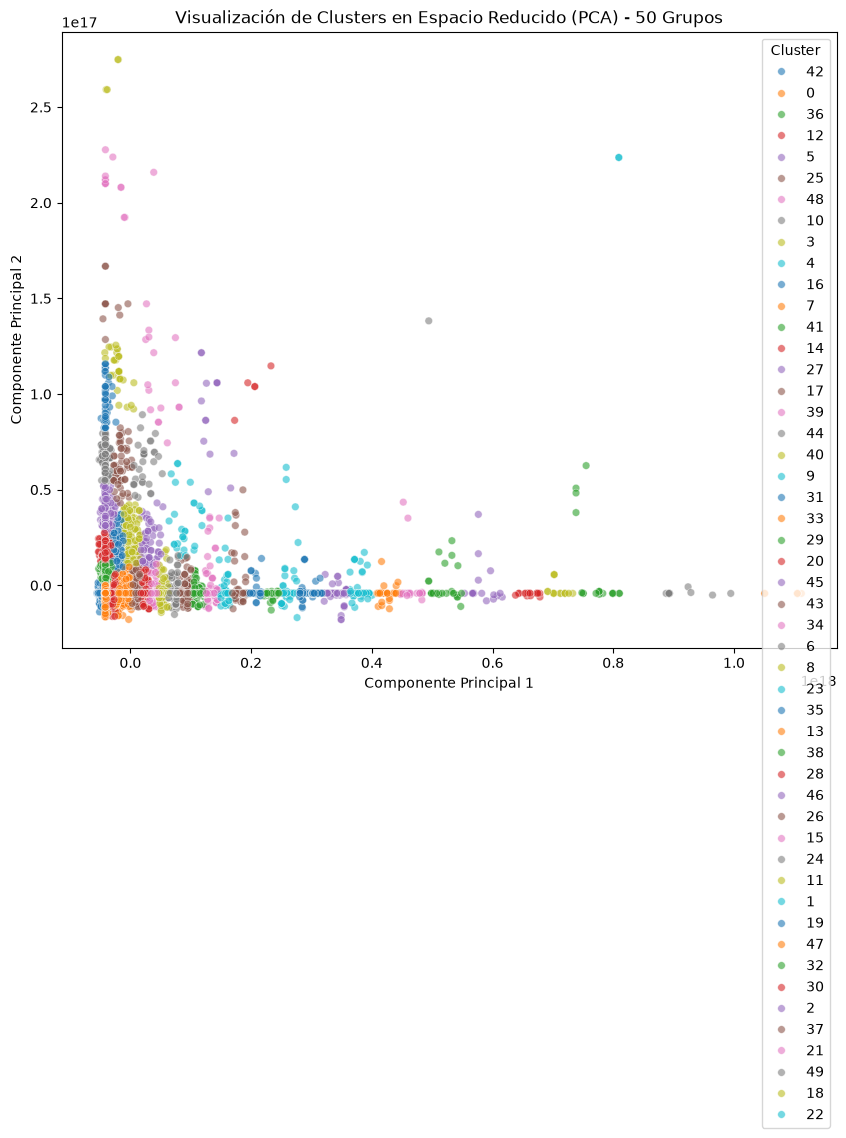

In [43]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Reducir la dimensionalidad de tus datos a 2D para poder graficarlos
pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X_anomalia_test) # O puedes usar X_test_enriquecido

# 2. Aplicar un clustering (por ejemplo, K-Means con un número razonable de grupos visuales, ej. 5 u 8)
n_clusters_visuales = 50
kmeans = KMeans(n_clusters=n_clusters_visuales, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_2d)

# 3. Preparar el DataFrame para la visualización con Seaborn
import pandas as pd
df_plot = pd.DataFrame({
    'PCA1': X_2d[:, 0],
    'PCA2': X_2d[:, 1],
    'Cluster': clusters.astype(str)
})

# 4. Graficar
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_plot, 
    x='PCA1', 
    y='PCA2', 
    hue='Cluster', 
    palette='tab10', 
    alpha=0.6, 
    s=30
)
plt.title(f"Visualización de Clusters en Espacio Reducido (PCA) - {n_clusters_visuales} Grupos")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.show()

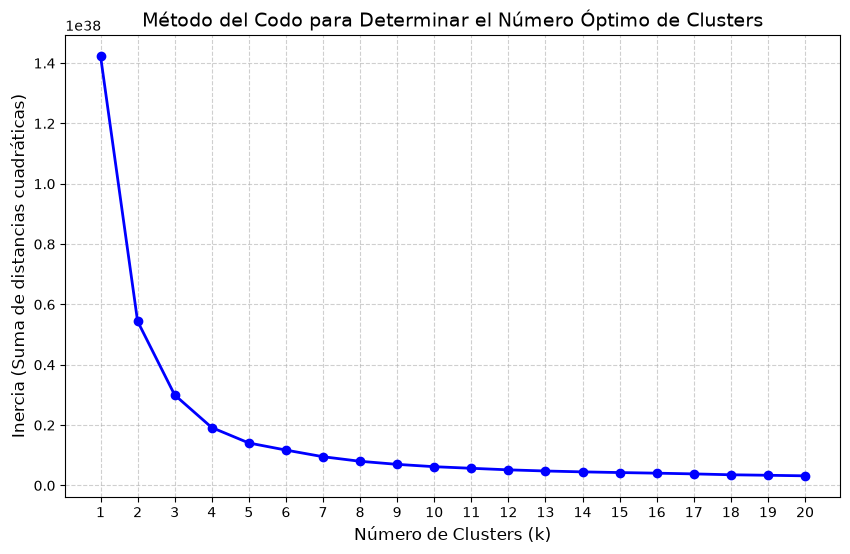

In [44]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Definir un rango razonable de número de clusters a probar (por ejemplo, de 1 a 20)
# Como tienes 53 clases pero quizás se agrupan en menos familias, 20 es un buen tope para buscar el codo.
inercia = []
rango_k = range(1, 21)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    kmeans.fit(X_anomalia_test) # O puedes usar X_anomalia_train
    inercia.append(kmeans.inertia_)

# 2. Graficar la curva del codo
plt.figure(figsize=(10, 6))
plt.plot(rango_k, inercia, marker='o', linestyle='-', color='b', linewidth=2, markersize=6)
plt.title("Método del Codo para Determinar el Número Óptimo de Clusters", fontsize=14)
plt.xlabel("Número de Clusters (k)", fontsize=12)
plt.ylabel("Inercia (Suma de distancias cuadráticas)", fontsize=12)
plt.xticks(rango_k)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Número óptimo de clusters según la Silueta: 2


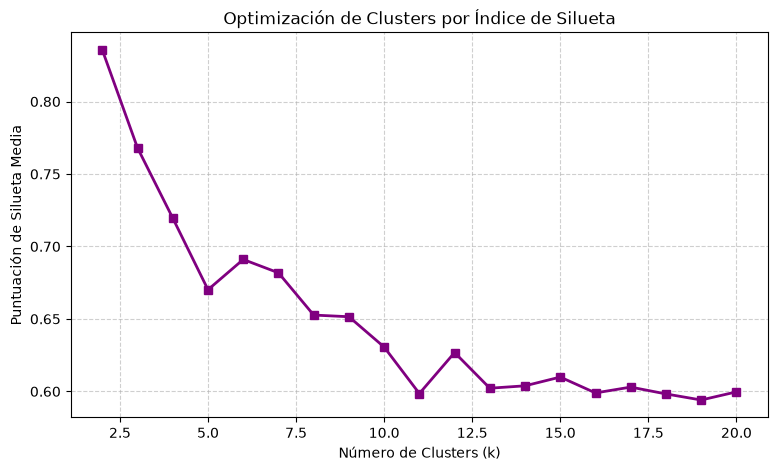

In [45]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Rango de clusters a evaluar (por ejemplo, de 2 a 20)
rango_k = range(2, 21)
valores_silueta = []

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    clusters = kmeans.fit_predict(X_anomalia_test)
    
    # Calcular el coeficiente de silueta medio para este k
    score = silhouette_score(X_anomalia_test, clusters)
    valores_silueta.append(score)

# Encontrar el k que maximiza la silueta
k_optimo_silueta = rango_k[valores_silueta.index(max(valores_silueta))]
print(f"Número óptimo de clusters según la Silueta: {k_optimo_silueta}")

# Gráfica opcional para la memoria del TFM
plt.figure(figsize=(9, 5))
plt.plot(rango_k, valores_silueta, marker='s', color='purple', linestyle='-', linewidth=2)
plt.title("Optimización de Clusters por Índice de Silueta")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Puntuación de Silueta Media")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

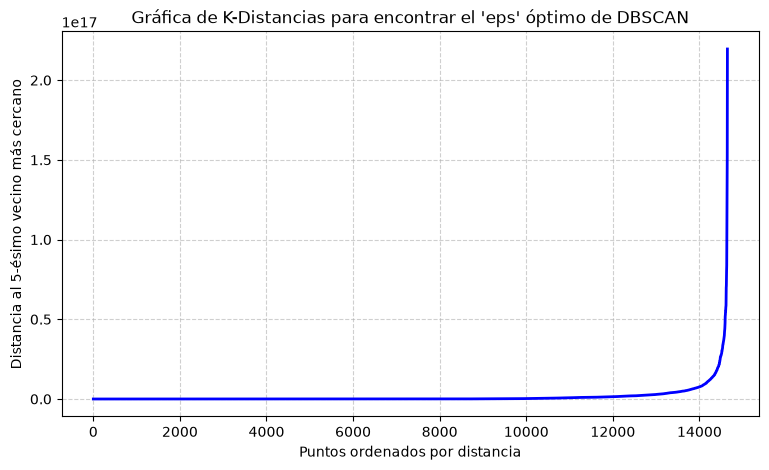


--- RESULTADOS ÓPTIMOS DE DBSCAN ---
Mejor eps encontrado: 28206924266331.7500
Número óptimo de clusters descubiertos: 353
Puntuación de Silueta (sin ruido): 0.9206
Porcentaje de muestras consideradas ruido (-1): 47.72%


In [46]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# 1. Encontrar automáticamente un valor óptimo de 'eps' usando la gráfica de k-distancias
# k se suele fijar en min_samples - 1 (por ejemplo, si min_samples = 5, k = 4)
min_samples_val = 5
neighbors = NearestNeighbors(n_neighbors=min_samples_val)
neighbors.fit(X_anomalia_test)
distances, _ = neighbors.kneighbors(X_anomalia_test)

# Ordenar las distancias del k-ésimo vecino más cercano de forma ascendente
k_distances = np.sort(distances[:, min_samples_val - 1])

# Visualizar la curva de k-distancias para buscar el "codo" visualmente si se desea
plt.figure(figsize=(9, 5))
plt.plot(k_distances, color='b', linewidth=2)
plt.title("Gráfica de K-Distancias para encontrar el 'eps' óptimo de DBSCAN")
plt.xlabel("Puntos ordenados por distancia")
plt.ylabel(f"Distancia al {min_samples_val}-ésimo vecino más cercano")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Automatizar una búsqueda rápida de un 'eps' que devuelva un número razonable de clusters válidos
# Probamos un rango de valores para eps basados en los percentiles de las distancias
mejores_clusters = 0
mejor_eps = 0
mejor_silueta = -1
mejor_etiquetas = None

# Probamos con varios umbrales de distancia
rango_eps = np.percentile(k_distances, np.linspace(50, 95, 10))

for eps_val in rango_eps:
    dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_val)
    etiquetas = dbscan.fit_predict(X_anomalia_test)
    
    # Contar cuántos clusters encontró (excluyendo el ruido, que se marca como -1)
    n_clusters_encontrados = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
    
    # Para calcular la silueta, DBSCAN requiere que haya al menos 2 clusters y que no todo sea ruido (-1)
    if n_clusters_encontrados > 1:
        # Filtramos temporalmente los puntos de ruido (-1) para calcular la silueta de los clusters reales
        mask_no_ruido = etiquetas != -1
        if sum(mask_no_ruido) > n_clusters_encontrados:
            score = silhouette_score(X_anomalia_test[mask_no_ruido], etiquetas[mask_no_ruido])
            
            # Guardamos la mejor combinación según la silueta
            if score > mejor_silueta:
                mejor_silueta = score
                mejor_eps = eps_val
                mejores_clusters = n_clusters_encontrados
                mejor_etiquetas = etiquetas

print(f"\n--- RESULTADOS ÓPTIMOS DE DBSCAN ---")
print(f"Mejor eps encontrado: {mejor_eps:.4f}")
print(f"Número óptimo de clusters descubiertos: {mejores_clusters}")
print(f"Puntuación de Silueta (sin ruido): {mejor_silueta:.4f}")

# Porcentaje de datos clasificados como ruido (etiqueta -1)
if mejor_etiquetas is not None:
    porcentaje_ruido = (sum(mejor_etiquetas == -1) / len(mejor_etiquetas)) * 100
    print(f"Porcentaje de muestras consideradas ruido (-1): {porcentaje_ruido:.2f}%")

### <span style="color:#2ca02c">4.8.2. DBSCAN</span>

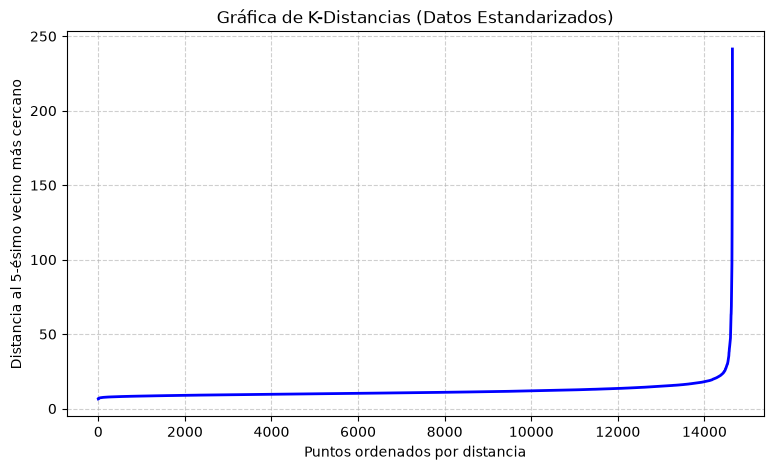


--- RESULTADOS DBSCAN (CON DATOS ESTANDARIZADOS) ---
Mejor eps encontrado: 15.9715
Número óptimo de clusters descubiertos: 18
Puntuación de Silueta (sin ruido): 0.2563
Porcentaje de muestras consideradas ruido (-1): 5.28%


In [47]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# 1. Estandarizar los datos correctamente
# (Asegúrate de usar el scaler ajustado previamente con tus datos de entrenamiento, 
# o instanciar uno nuevo si es un bloque de análisis exploratorio puro)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_anomalia_test)

# 2. Encontrar automáticamente un valor óptimo de 'eps' usando la gráfica de k-distancias
min_samples_val = 5
neighbors = NearestNeighbors(n_neighbors=min_samples_val)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)

# Ordenar las distancias del k-ésimo vecino más cercano
k_distances = np.sort(distances[:, min_samples_val - 1])

# Visualizar la curva de k-distancias para verificar el "codo" con los datos escalados
plt.figure(figsize=(9, 5))
plt.plot(k_distances, color='b', linewidth=2)
plt.title("Gráfica de K-Distancias (Datos Estandarizados)")
plt.xlabel("Puntos ordenados por distancia")
plt.ylabel(f"Distancia al {min_samples_val}-ésimo vecino más cercano")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Búsqueda automatizada del mejor 'eps' basada en la silueta y un nivel de ruido razonable
mejores_clusters = 0
mejor_eps = 0
mejor_silueta = -1
mejor_etiquetas = None

# Probamos con varios percentiles del rango de distancias
rango_eps = np.percentile(k_distances, np.linspace(50, 95, 15))

for eps_val in rango_eps:
    dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_val)
    etiquetas = dbscan.fit_predict(X_scaled)
    
    # Contar clusters encontrados (excluyendo el ruido -1)
    n_clusters_encontrados = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
    
    if n_clusters_encontrados > 1:
        mask_no_ruido = etiquetas != -1
        if sum(mask_no_ruido) > n_clusters_encontrados:
            score = silhouette_score(X_scaled[mask_no_ruido], etiquetas[mask_no_ruido])
            
            if score > mejor_silueta:
                mejor_silueta = score
                mejor_eps = eps_val
                mejores_clusters = n_clusters_encontrados
                mejor_etiquetas = etiquetas

print(f"\n--- RESULTADOS DBSCAN (CON DATOS ESTANDARIZADOS) ---")
print(f"Mejor eps encontrado: {mejor_eps:.4f}")
print(f"Número óptimo de clusters descubiertos: {mejores_clusters}")
print(f"Puntuación de Silueta (sin ruido): {mejor_silueta:.4f}")

if mejor_etiquetas is not None:
    porcentaje_ruido = (sum(mejor_etiquetas == -1) / len(mejor_etiquetas)) * 100
    print(f"Porcentaje de muestras consideradas ruido (-1): {porcentaje_ruido:.2f}%")

--- CÁLCULO AUTOMÁTICO ---
Valor de 'eps' óptimo detectado en el codo: 28.5714

--- RESULTADOS FINALES DE DBSCAN ---
Número de clusters identificados: 8
Porcentaje de muestras consideradas ruido (-1): 0.67%
Puntuación de Silueta (sin ruido): 0.4907


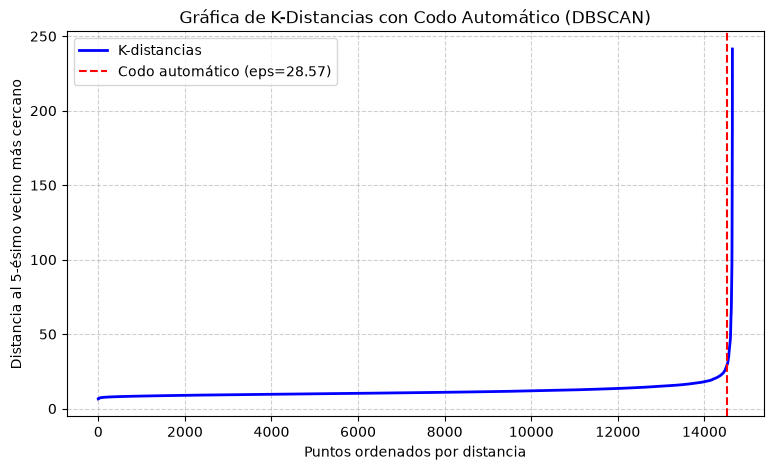

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator

# 1. Estandarizar los datos correctamente
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_anomalia_test)

# 2. Encontrar las k-distancias para el cálculo automático
min_samples_val = 5
neighbors = NearestNeighbors(n_neighbors=min_samples_val)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)

# Ordenar las distancias del k-ésimo vecino más cercano
k_distances = np.sort(distances[:, min_samples_val - 1])
puntos_x = np.arange(len(k_distances))

# 3. Detectar automáticamente el "codo" en la curva de K-distancias usando KneeLocator
kneedle = KneeLocator(
    puntos_x, 
    k_distances, 
    curve='convex', 
    direction='increasing'
)

eps_optimo = kneedle.elbow_y

# Si por algún motivo el localizador automático no devolviera un valor, usamos un percentil de seguridad
if eps_optimo is None:
    eps_optimo = np.percentile(k_distances, 95)

print(f"--- CÁLCULO AUTOMÁTICO ---")
print(f"Valor de 'eps' óptimo detectado en el codo: {eps_optimo:.4f}")

# 4. Ejecutar DBSCAN con el 'eps' calculado automáticamente
dbscan = DBSCAN(eps=eps_optimo, min_samples=min_samples_val)
etiquetas = dbscan.fit_predict(X_scaled)

# 5. Analizar los resultados obtenidos
n_clusters_encontrados = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
porcentaje_ruido = (sum(etiquetas == -1) / len(etiquetas)) * 100

print(f"\n--- RESULTADOS FINALES DE DBSCAN ---")
print(f"Número de clusters identificados: {n_clusters_encontrados}")
print(f"Porcentaje de muestras consideradas ruido (-1): {porcentaje_ruido:.2f}%")

if n_clusters_encontrados > 1:
    mask_no_ruido = etiquetas != -1
    if sum(mask_no_ruido) > n_clusters_encontrados:
        score_silueta = silhouette_score(X_scaled[mask_no_ruido], etiquetas[mask_no_ruido])
        print(f"Puntuación de Silueta (sin ruido): {score_silueta:.4f}")

# 6. Mostrar la gráfica señalando el codo detectado
plt.figure(figsize=(9, 5))
plt.plot(puntos_x, k_distances, color='b', linewidth=2, label='K-distancias')
if kneedle.elbow is not None:
    plt.axvline(x=kneedle.elbow, color='r', linestyle='--', label=f'Codo automático (eps={eps_optimo:.2f})')
plt.title("Gráfica de K-Distancias con Codo Automático (DBSCAN)")
plt.xlabel("Puntos ordenados por distancia")
plt.ylabel(f"Distancia al {min_samples_val}-ésimo vecino más cercano")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [41]:
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# 1. Obtener el vector de clasificación (etiquetas predichas por DBSCAN)
# 'etiquetas' es el array que devolvió el modelo DBSCAN (valores de -1 a 7)
vector_clusters = etiquetas

# 2. Crear un DataFrame analítico cruzando los clusters con tus etiquetas reales
df_cruce = pd.DataFrame({
    'Cluster_DBSCAN': vector_clusters,
    'Etiqueta_Real': Y_test_etiquetas  # Asegúrate de que esta variable contenga tus 53 clases reales
})

# 3. Generar la Matriz de Contingencia (Tabla cruzada)
# Filas = Clusters de DBSCAN (incluyendo el -1 como ruido), Columnas = Tus 53 clases reales (o puedes ver una muestra)
matriz_contingencia = pd.crosstab(df_cruce['Cluster_DBSCAN'], df_cruce['Etiqueta_Real'])

print("--- MATRIZ DE CONTINGENCIA (Clusters vs Clases Reales) ---")
print("Dimensiones de la matriz:", matriz_contingencia.shape)
# Mostramos una pequeña porción para visualizarlo cómodamente en consola
print(matriz_contingencia.iloc[:, :]) 

# 4. Calcular métricas de relación / concordancia externa
# (Nota: Omitimos temporalmente el ruido -1 para evaluar qué tan bien agrupados están los puntos válidos)
mask_evaluacion = vector_clusters != -1
if sum(mask_evaluacion) > 0:
    y_real_filtrado = Y_test_etiquetas[mask_evaluacion]
    y_pred_filtrado = vector_clusters[mask_evaluacion]

    ari = adjusted_rand_score(y_real_filtrado, y_pred_filtrado)
    nmi = normalized_mutual_info_score(y_real_filtrado, y_pred_filtrado)

    print(f"\n--- MÉTRICAS DE CONCORDANCIA EXTERNA ---")
    print(f"Adjusted Rand Index (ARI): {ari:.4f}  (0 = azar, 1 = coincidencia perfecta)")
    print(f"Normalized Mutual Information (NMI): {nmi:.4f}  (Mide cuánta información comparten)")

--- MATRIZ DE CONTINGENCIA (Clusters vs Clases Reales) ---
Dimensiones de la matriz: (9, 53)
Etiqueta_Real   access_token_auth_header_error_401  \
Cluster_DBSCAN                                       
-1                                               1   
 0                                             288   
 1                                               0   
 2                                               0   
 3                                               0   
 4                                               1   
 5                                               0   
 6                                               0   
 7                                               0   

Etiqueta_Real   access_token_authorization_form_401  \
Cluster_DBSCAN                                        
-1                                                2   
 0                                              294   
 1                                                0   
 2                                   

# <span style="color:#2ca02c">5. Analisis de importancia de caracteristicas</span>

In [44]:
# 1. Definir un umbral (threshold) basado en el error de entrenamiento o validación
# (Por ejemplo, usando el percentil 95 del error MSE en tu conjunto de entrenamiento 'correct')
reconstructed_train = autoencoder_final.predict(X_correct_train, verbose=0)
train_mse = np.mean(np.square(X_correct_train - reconstructed_train), axis=1)
threshold = np.percentile(train_mse, 95)
print(f"Umbral de anomalía establecido en: {threshold:.6f}")

# 2. Función predictora compatible con scikit-learn / permutation_importance
def predict_autoencoder_labels(estimator, X):
    reconstructed = estimator.predict(X, verbose=0)
    mse = np.mean(np.square(X - reconstructed), axis=1)
    # Si el error supera el umbral es anómalo (-1), si no, es correcto (1)
    predictions = np.where(mse > threshold, -1, 1)
    return predictions

# 3. Función wrapper personalizada para que permutation_importance pueda evaluar el modelo de Keras
from sklearn.base import BaseEstimator, ClassifierMixin

class AutoencoderClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model, threshold):
        self.model = model
        self.threshold = threshold
        self.classes_ = np.array([-1, 1]) # Requerido por scikit-learn para clasificación binaria
        
    def fit(self, X, y=None):
        return self
        
    def predict(self, X):
        return predict_autoencoder_labels(self.model, X)

# Instanciar el wrapper para el Autoencoder
wrapped_model = AutoencoderClassifierWrapper(autoencoder_final, threshold)

# 4. Preparar Y_test tal como lo tenías
Y_test = df_result.loc[idx_test, 'label'].apply(lambda x: 1 if x == 'correct' else -1).values

# 5. Calcular la importancia de las características por permutación
print("Calculando la importancia de las características...")
result = permutation_importance(
    wrapped_model, X_test, Y_test, 
    scoring='f1',
    n_repeats=5,  # Reducido ligeramente a 5 si el dataset de test es muy grande para acelerar el cálculo
    random_state=SEED, 
    n_jobs=-1
)

# 6. Crear el DataFrame de importancia
df_importancia = pd.DataFrame({
    'Caracteristica': lista_metric_name_vector,
    'Importancia': result.importances_mean
}).sort_values(by='Importancia', ascending=False)

print("\nTop 10 características más importantes para el Autoencoder:")
print(df_importancia.head(10))

Umbral de anomalía establecido en: 0.178090
Calculando la importancia de las características...

Top 10 características más importantes para el Autoencoder:
                                        Caracteristica  Importancia
119           go_gc_duration_seconds_count_diff(lag_1)     0.323987
122          go_memstats_alloc_bytes_total_diff(lag_1)     0.323234
130              go_memstats_mallocs_total_diff(lag_1)     0.320277
197              process_cpu_seconds_total_diff(lag_1)     0.319045
138  net_conntrack_listener_conn_accepted_total_dif...     0.318402
202  prometheus_engine_query_duration_seconds_count...     0.318402
204  prometheus_engine_query_samples_total_diff(lag_1)     0.318402
139  net_conntrack_listener_conn_closed_total_diff(...     0.318402
18                        go_memstats_sys_bytes(lag_0)     0.310376
136                       go_memstats_sys_bytes(lag_1)     0.292340


In [45]:
with pd.option_context('display.max_rows', None):
    display(df_importancia)

,Caracteristica,Importancia
119,go_gc_duration_seconds_count_diff(lag_1),3.239869e-01
122,go_memstats_alloc_bytes_total_diff(lag_1),3.232338e-01
130,go_memstats_mallocs_total_diff(lag_1),3.202770e-01
197,process_cpu_seconds_total_diff(lag_1),3.190445e-01
138,net_conntrack_listener_conn_accepted_total_dif...,3.184020e-01
202,prometheus_engine_query_duration_seconds_count...,3.184020e-01
204,prometheus_engine_query_samples_total_diff(lag_1),3.184020e-01
139,net_conntrack_listener_conn_closed_total_diff(...,3.184020e-01
18,go_memstats_sys_bytes(lag_0),3.103761e-01
136,go_memstats_sys_bytes(lag_1),2.923396e-01


In [47]:
with pd.option_context('display.max_rows', None):
    display(df_importancia)
print(df_importancia[df_importancia['Importancia']<0].shape)
lista_features_poco_importantes=df_importancia[df_importancia['Importancia']<=0]['Caracteristica'].tolist()
#lista_features_poco_importantes = [re.sub(r'\s*\(.*?\)', '', cadena) for cadena in lista_features_poco_importantes]
lista_features_poco_importantes = list(set(lista_features_poco_importantes))
print(len(lista_features_poco_importantes))

,Caracteristica,Importancia
119,go_gc_duration_seconds_count_diff(lag_1),3.239869e-01
122,go_memstats_alloc_bytes_total_diff(lag_1),3.232338e-01
130,go_memstats_mallocs_total_diff(lag_1),3.202770e-01
197,process_cpu_seconds_total_diff(lag_1),3.190445e-01
138,net_conntrack_listener_conn_accepted_total_dif...,3.184020e-01
202,prometheus_engine_query_duration_seconds_count...,3.184020e-01
204,prometheus_engine_query_samples_total_diff(lag_1),3.184020e-01
139,net_conntrack_listener_conn_closed_total_diff(...,3.184020e-01
18,go_memstats_sys_bytes(lag_0),3.103761e-01
136,go_memstats_sys_bytes(lag_1),2.923396e-01


(5, 2)
44


In [49]:
lista_metric_name_reducida_AE=[]
lista_idx_reducida_AE=[]
ID=0
for metric_name in lista_metric_name_vector:
    if not metric_name in lista_features_poco_importantes:
        lista_metric_name_reducida_AE.append(metric_name)
        lista_idx_reducida_AE.append(ID)
    ID+=1
        
        




In [51]:
len(lista_metric_name_reducida_AE)

310

In [33]:
X_matrix_reducida      = X_matrix[:, lista_idx_reducida_IF]
X_correct_train        = X_matrix_reducida[idx_correct_train]
X_test                 = X_matrix_reducida[idx_test]

In [53]:
input_dim = X_correct_train.shape[1]

#1. Recuperamos los parametros de la optimizacion

best_params = study.best_params
print("=== CONFIGURACIÓN DEFINITIVA ===")
print(best_params)

# 2. Instanciar el modelo usando TU función original de creación
#input_dim = X_correct_train.shape[1]
autoencoder_final = create_autoencoder(
    latent_dim=best_params['latent_dim'],
    hidden_units=best_params['hidden_units'],
    learning_rate=best_params['learning_rate'],
    input_dim=input_dim
)

# 3. Configurar Early Stopping con más paciencia para exprimir el entrenamiento
early_stopping_final = EarlyStopping(
    monitor='loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# 4. Entrenar con un número mayor de épocas (ej: 200) respaldado por tu función
epochs_final = 500

print("\nIniciando entrenamiento del modelo definitivo...")
history_final = autoencoder_final.fit(
    X_correct_train, X_correct_train,
    batch_size=best_params['batch_size'],
    epochs=epochs_final,
    callbacks=[early_stopping_final],
    verbose=1  # verbose=1 para ver la evolución en directo
)

print(f"\n¡Entrenamiento finalizado!")
print(f"Épocas reales ejecutadas: {len(history_final.history['loss'])} / {epochs_final}")
print(f"Loss (MSE) final: {history_final.history['loss'][-1]:.6f}")

=== CONFIGURACIÓN DEFINITIVA ===
{'latent_dim': 32, 'hidden_units': 64, 'learning_rate': 0.005, 'batch_size': 32, 'epochs': 100}

Iniciando entrenamiento del modelo definitivo...
Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2068
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1629
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1512
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1441
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1395
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1371
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1357
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - loss: 0.1339
Epoch 9/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - loss: 0.1320
Epoch 10/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1315
Epoch 11/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step - loss: 0.1307
Epoch 12/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step - loss: 0

In [54]:
autoencoder = autoencoder_final

In [55]:
# 1. Calculas los errores en el train limpio
reconstructions_train = autoencoder.predict(X_correct_train)
train_scores = np.mean(np.power(X_correct_train - reconstructions_train, 2), axis=1)

# 2. Defines el umbral basándote en el train (ej. el percentil 95 o 99 de los normales)
threshold_percentil_scores = 99.9
threshold = np.percentile(train_scores, threshold_percentil_scores)

320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step



Calculando errores de reconstrucción en el conjunto de test...
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 517us/step


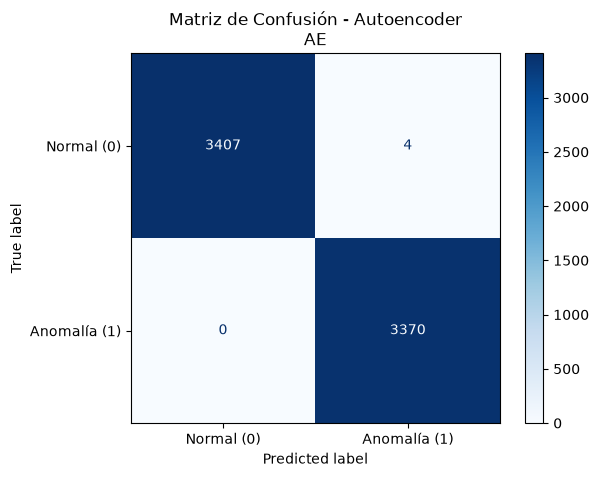

In [56]:
# Calcular los scores (Error de reconstrucción MSE por muestra) para X_test
print("\nCalculando errores de reconstrucción en el conjunto de test...")
reconstructions = autoencoder.predict(X_test)
scores = np.mean(np.power(X_test - reconstructions, 2), axis=1)

reconstructions_train = autoencoder.predict(X_correct_train)
train_scores = np.mean(np.power(X_correct_train - reconstructions_train, 2), axis=1)


# Predicción: Si el MSE supera el umbral es anomalía (1), si no, normal (0)
Y_pred = np.where(scores > threshold, 1, 0)

model_name = f'AE_v1'



df_result[f'result_({model_name})'] = float('nan')
df_result[f'scores_({model_name})'] = float('nan')
df_result.loc[idx_test, f'result_({model_name})'] = Y_pred
df_result.loc[idx_test, f'scores_({model_name})'] = scores

# Mapeo de etiquetas reales (0 = normal/correct, 1 = anomalía)
y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
y_pred = df_result.loc[idx_test, f'result_({model_name})']

# 1. Componentes de la matriz de confusión
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

# 2. Cálculo de métricas
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred, zero_division=0)

parametros = best_params.copy()
parametros['threshold_percentil_scores'] = threshold_percentil_scores


# 3. Guardar en el registro
reg_resultado_algoritmo = {
    'test_name': model_name,
    'parametros': json.dumps(parametros),
    'TP': int(tp),
    'FP': int(fp),
    'TN': int(tn),
    'FN': int(fn),
    'accuracy': float(acc),
    'precision': float(precision),
    'recall': float(recall),
    'specificity': float(specificity),
    'f1_score': float(f1)
}

# Si quieres mantener la estructura de lista para un DataFrame posterior:
lista_result.append(reg_resultado_algoritmo)
df_anomaly_detection_summary = pd.DataFrame(lista_result)

# 4. Visualizar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomalía (1)'])
disp.plot(cmap='Blues')
plt.title(f'Matriz de Confusión - Autoencoder\n{model_name}')
plt.show()